# Project: Volatility Forecasting

In this project, you will perform a comparative analysis of various volatility forecasting methods in the spirit of Artur Sepp's paper *Volatility Modeling and Trading*:

1. close-to-close
2. parkinson
3. garman-klass
4. rogers-sachell
5. yang-zang
6. garch(1, 1)


For both Part 1 & 2 below, you will need implement the all six estimators (close-to-close, parkinson, garman-klass, rogers-sachell, yang-zang and garch(1, 1)) in code.  

Hint: they way I implement these estimators is as aggregation functions that are applied to daily returns in a `.groupby()`, but this isn't strictly necessary - see `sum_product_hint.ipynb` for more details.

**Part 1: Code Implementation and Verification (Jupyter Notebook) -- 100 pts**
1. For the backtest period starting from 1/1/2005 and ending on 4/2/2016, calculate the regression coefficient and $R^2$ metric for *weekly* forecasts for each of the estimators, and compare your results to Sepp's (pg. 41). Do this ONLY for SPY.

**Grading Rubric:**
- accuracy of results: 50 pts
- code commenting: 25 pts
- readability of notebook: 25 pts


**Part 2: Backtest (Jupyter Notebook & Quarto Report) -- 100 pts**

In this backtest, you will apply the six volatility estimators to 10 ETFs in `etf_universe.csv` of your choosing.  Your analysis should include the following:

1. You will determine the length of the backtest based on data availability, but it should be at least five years.  It should go up until the present.  
2. You will use Sepp's $R^2$ metric, and another metric of your choosing (or creation). Give a justification for your metric, and why it makes sense.
3. Your final conclusion will be your choice of forecast methodology if you were making investment decisions based on these forecasts.  Justify your answer with your analysis.
4. Your analysis should include readable prose, and at least 2 visualizations.  You will be graded on the neatness and communication quality of your notebook and report.
5. Include all your code in a Jupyter Notebook and produce a Quarto (HTML) document report.

Note: GARCH will probably take a few minutes to run for each underlying, so I would suggest getting started on this first to make sure you have the data that you need.  Make sure to save your garch forecasts in a CSV, so the grader doesn't have to run code that takes a long time to finish.
   
**Grading Rubric:**
- accuracy of results: 50 pts
- writing/presentation quality: 35 pts
- code commenting: 15 pts

## Part 1

In [54]:
import pandas as pd
import numpy as np
import sklearn
from arch import arch_model
from math import sqrt
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [5]:
ticker = "SPY"
start_date = "2005-01-01"
end_date = "2016-04-02"

df_spy = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)

# Flatten columns if MultiIndex
if isinstance(df_spy.columns, pd.MultiIndex):
    df_spy.columns = [col[0] for col in df_spy.columns]

df_spy = df_spy.reset_index()
df_spy = df_spy[["Date", "Open", "High", "Low", "Close", "Volume"]]

df_spy.head()

[*********************100%***********************]  1 of 1 completed


,Date,Open,High,Low,Close,Volume
0,2005-01-03,121.559998,121.760002,119.900002,120.300003,55748000
1,2005-01-04,120.459999,120.540001,118.440002,118.830002,69167600
2,2005-01-05,118.739998,119.250000,118.000000,118.010002,65667300
3,2005-01-06,118.440002,119.150002,118.260002,118.610001,47814700
4,2005-01-07,118.970001,119.230003,118.129997,118.440002,55847700


In [6]:
df_spy['Date'] = pd.to_datetime(df_spy['Date'], errors='coerce', dayfirst=True)
df_spy

,Date,Open,High,Low,Close,Volume
0,2005-01-03,121.559998,121.760002,119.900002,120.300003,55748000
1,2005-01-04,120.459999,120.540001,118.440002,118.830002,69167600
2,2005-01-05,118.739998,119.250000,118.000000,118.010002,65667300
3,2005-01-06,118.440002,119.150002,118.260002,118.610001,47814700
4,2005-01-07,118.970001,119.230003,118.129997,118.440002,55847700
...,...,...,...,...,...,...
2826,2016-03-28,203.610001,203.860001,202.710007,203.240005,62408200
2827,2016-03-29,202.759995,205.250000,202.399994,205.119995,92922900
2828,2016-03-30,206.300003,206.869995,205.589996,206.020004,86365300
2829,2016-03-31,205.910004,206.410004,205.330002,205.520004,94584100


### creating weekly segregation

In [8]:
weekday = df_spy['Date'].dt.weekday
weekday

0       0
1       1
2       2
3       3
4       4
       ..
2826    0
2827    1
2828    2
2829    3
2830    4
Name: Date, Length: 2831, dtype: int32

In [100]:
# creating the array of week numbers
week_num = []
ix_week = 0
week_num.append(ix_week)
for ix in range(0, len(weekday) - 1):
    prev_day = weekday[ix]
    curr_day = weekday[ix + 1]
    if curr_day < prev_day:
        ix_week = ix_week + 1
    week_num.append(ix_week)
np.array(week_num) # I use the array function simply because it looks better when it prints

array([  0,   0,   0, ..., 508, 508, 508], shape=(2453,))

In [10]:
df_spy.insert(2, 'week_num', week_num)
df_spy

,Date,Open,week_num,High,Low,Close,Volume
0,2005-01-03,121.559998,0,121.760002,119.900002,120.300003,55748000
1,2005-01-04,120.459999,0,120.540001,118.440002,118.830002,69167600
2,2005-01-05,118.739998,0,119.250000,118.000000,118.010002,65667300
3,2005-01-06,118.440002,0,119.150002,118.260002,118.610001,47814700
4,2005-01-07,118.970001,0,119.230003,118.129997,118.440002,55847700
...,...,...,...,...,...,...,...
2826,2016-03-28,203.610001,586,203.860001,202.710007,203.240005,62408200
2827,2016-03-29,202.759995,586,205.250000,202.399994,205.119995,92922900
2828,2016-03-30,206.300003,586,206.869995,205.589996,206.020004,86365300
2829,2016-03-31,205.910004,586,206.410004,205.330002,205.520004,94584100


In [102]:
# A dataframe of week start and week end dates
df_start_end = (
    df_spy.groupby(['week_num'], as_index=False)[['Date']]
    .agg(['min', 'max'])['Date']
    .rename(columns={'min': 'week_start', 'max': 'week_end'})
    .reset_index()
    .rename(columns={'index': 'week_num'})
)

df_start_end

,week_num,week_start,week_end
0,0,2005-01-03,2005-01-07
1,1,2005-01-10,2005-01-14
2,2,2005-01-18,2005-01-21
3,3,2005-01-24,2005-01-28
4,4,2005-01-31,2005-02-04
...,...,...,...
582,582,2016-02-29,2016-03-04
583,583,2016-03-07,2016-03-11
584,584,2016-03-14,2016-03-18
585,585,2016-03-21,2016-03-24


#### Merging weekly columns

In [13]:
## Merging the weekly columns
df_spy = df_spy.merge(df_start_end)
df_spy

,Date,Open,week_num,High,Low,Close,Volume,week_start,week_end
0,2005-01-03,121.559998,0,121.760002,119.900002,120.300003,55748000,2005-01-03,2005-01-07
1,2005-01-04,120.459999,0,120.540001,118.440002,118.830002,69167600,2005-01-03,2005-01-07
2,2005-01-05,118.739998,0,119.250000,118.000000,118.010002,65667300,2005-01-03,2005-01-07
3,2005-01-06,118.440002,0,119.150002,118.260002,118.610001,47814700,2005-01-03,2005-01-07
4,2005-01-07,118.970001,0,119.230003,118.129997,118.440002,55847700,2005-01-03,2005-01-07
...,...,...,...,...,...,...,...,...,...
2826,2016-03-28,203.610001,586,203.860001,202.710007,203.240005,62408200,2016-03-28,2016-04-01
2827,2016-03-29,202.759995,586,205.250000,202.399994,205.119995,92922900,2016-03-28,2016-04-01
2828,2016-03-30,206.300003,586,206.869995,205.589996,206.020004,86365300,2016-03-28,2016-04-01
2829,2016-03-31,205.910004,586,206.410004,205.330002,205.520004,94584100,2016-03-28,2016-04-01


### This function (compute_weekly_vol) computes weekly annualized volatility using six well-known estimators: 
#### Close-to-Close, Parkinson, Garman–Klass, Rogers–Satchell, Yang–Zhang, and GARCH(1,1)
Each estimator captures volatility from different aspects of price movements (range-based, open–close variation, or conditional variance modeling). The function groups daily data by week, applies all six formulas, and returns a consolidated DataFrame of weekly volatility measures for direct model comparison.

In [126]:
def compute_weekly_vol(df):
    weekly_vols = []
    df['log_ret'] = np.log(df['Close'] / df['Close'].shift(1))

    for week, group in df.groupby('week_num'):
        # Close-to-close realized vol
        ret = group['Close'].pct_change().dropna()
        realized_vol = ret.std() * np.sqrt(252)

        # Parkinson
        hl_log = np.log(group['High']/group['Low'])
        parkinson = np.sqrt((1/(4*np.log(2)))*np.mean(hl_log**2)) * np.sqrt(252)

        # Garman-Klass
        oc_log = np.log(group['Close']/group['Open'])
        gk = np.sqrt(np.mean(0.5*hl_log**2 - (2*np.log(2)-1)*oc_log**2)) * np.sqrt(252)

        # Rogers-Satchell
        ho_log = np.log(group['High']/group['Open'])
        hc_log = np.log(group['High']/group['Close'])
        lo_log = np.log(group['Low']/group['Open'])
        lc_log = np.log(group['Low']/group['Close'])
        rs = np.sqrt(np.mean(ho_log*hc_log + lo_log*lc_log)) * np.sqrt(252)

        # Yang-Zhang
        log_oc = np.log(group['Open']/group['Close'].shift(1))
        log_co = np.log(group['Close']/group['Open'])
        sigma_oc2 = np.var(log_oc.dropna())
        sigma_co2 = np.var(log_co.dropna())
        sigma_rs2 = np.mean(ho_log*hc_log + lo_log*lc_log)
        k = 0.34 / (1.34 + (len(group)-1)/(len(group)-1))
        yz = np.sqrt(sigma_oc2 + k*sigma_co2 + (1-k)*sigma_rs2) * np.sqrt(252)

        # GARCH(1,1) using rolling history
        hist_ret = df.loc[df['week_num'] < week, 'log_ret'].dropna()
        if len(hist_ret) >= 20: # skipping first few weeks to finalize parameters
            am = arch_model(hist_ret * 100, vol='Garch', p=1, q=1)
            res = am.fit(disp='off')
            fcast = res.forecast(horizon=1)
            garch_var = fcast.variance.values[-1, 0]
            garch_vol = np.sqrt(garch_var) / 100 * np.sqrt(252)
        else:
            garch_vol = np.nan

        weekly_vols.append({
            'week_num': week,
            'week_start': group['week_start'].iloc[0],
            'week_end': group['week_end'].iloc[0],
            'realized_vol': realized_vol,
            'parkinson_vol': parkinson,
            'gk_vol': gk,
            'rs_vol': rs,
            'yz_vol': yz,
            'garch_vol': garch_vol
        })

    return pd.DataFrame(weekly_vols)

In [16]:
df_weekly_vol = compute_weekly_vol(df_spy)
df_weekly_vol

,week_num,week_start,week_end,realized_vol,parkinson_vol,gk_vol,rs_vol,yz_vol,garch_vol
0,0,2005-01-03,2005-01-07,0.117734,0.120518,0.115063,0.110156,0.109913,NaN
1,1,2005-01-10,2005-01-14,0.108571,0.085756,0.087781,0.089740,0.095334,NaN
2,2,2005-01-18,2005-01-21,0.039905,0.107782,0.089608,0.075553,0.094043,NaN
3,3,2005-01-24,2005-01-28,0.021904,0.066081,0.074419,0.082389,0.081909,NaN
4,4,2005-01-31,2005-02-04,0.088881,0.073116,0.067922,0.063900,0.066122,NaN
...,...,...,...,...,...,...,...,...,...
582,582,2016-02-29,2016-03-04,0.155924,0.126361,0.121252,0.116514,0.130817,0.177034
583,583,2016-03-07,2016-03-11,0.177390,0.121619,0.134788,0.142715,0.160727,0.171311
584,584,2016-03-14,2016-03-18,0.068805,0.083877,0.083794,0.079714,0.081277,0.162501
585,585,2016-03-21,2016-03-24,0.055998,0.065407,0.064249,0.061702,0.066268,0.131054


#### Calculating regression stats, beta and r^2 for the calculated vols

In [18]:
def regression_stats(x, y):
    mask = (~np.isnan(x)) & (~np.isnan(y))
    X = x[mask].values.reshape(-1, 1)
    Y = y[mask].values
    reg = LinearRegression().fit(X, Y)
    return reg.coef_[0], reg.score(X, Y)

results = {}
for col in ['parkinson_vol','gk_vol','rs_vol','yz_vol','garch_vol']:
    beta, r2 = regression_stats(df_weekly_vol[col], df_weekly_vol['realized_vol'])
    results[col] = {"beta": beta, "R2": r2}

pd.DataFrame(results).T

,beta,R2
parkinson_vol,0.991459,0.670549
gk_vol,0.947658,0.641997
rs_vol,0.889219,0.611904
yz_vol,0.836020,0.670446
garch_vol,0.813887,0.488654


### Conclusion

#### The above tabel sugegst that **parkinson_vol & Yang-Zang** R^2 is best among all other estimators and Garch(1,1) has the least R^2

## Part 2

#### Selecting 10 ETFs

In [21]:
etfs = pd.read_csv("etf_universe.csv")
symbols = etfs['ticker'].dropna().unique()[2:12]   # picking 10 ETFs

#### Taking data from 2016 to most recent and adding the week end and week start columns

In [22]:
start_date = "2016-01-01"
end_date = "2025-10-04"

data = {}
for sym in symbols:
    df = yf.download(sym, start=start_date, end=end_date, auto_adjust=False)
    df = df.reset_index()

    # flatten MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)

    # week_num creation
    weekday = df['Date'].dt.weekday
    week_num = []
    ix_week = 0
    week_num.append(ix_week)
    for ix in range(0, len(weekday) - 1):
        prev_day = weekday[ix]
        curr_day = weekday[ix + 1]
        if curr_day < prev_day:
            ix_week += 1
        week_num.append(ix_week)
    df.insert(2, 'week_num', week_num)

    # week_start / week_end aggregation
    df_start_end = df.groupby('week_num')['Date'].agg(
        week_start='min',
        week_end='max'
    ).reset_index()

    df = df.merge(df_start_end, on='week_num', how='left')

    df['log_ret'] = np.log(df['Close'] / df['Close'].shift(1))
    data[sym] = df.dropna()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Choice of Evaluation Metric — Mean Squared Error (MSE)

We use **Mean Squared Error (MSE)** as the primary metric to evaluate volatility estimators because it directly measures the **average squared deviation** between the forecasted volatility and the realized (observed) volatility.

Mathematically,

$$
\text{MSE} = \frac{1}{n}\sum_{t=1}^{n}(\hat{\sigma}_t - \sigma_t^{\text{realized}})^2
$$

This criterion has several advantages:

1. **Penalty on large errors:** Squaring emphasizes larger deviations, which is crucial in volatility modeling since underestimating volatility during turbulent periods can lead to substantial risk mispricing.

2. **Scale consistency:** MSE is expressed in the same squared units as volatility, making comparisons across models straightforward.

3. **Model-agnostic:** Unlike $R^2$, which depends on correlation structure, MSE purely captures forecast accuracy regardless of directionality or scale shifts.

4. **Standard benchmark:** It is widely used in volatility forecasting literature and risk management to assess how well conditional variance models predict future realized variance.

Therefore, MSE provides a robust quantitative measure of **forecast precision** — lower MSE values indicate that a volatility estimator produces predictions closer to the true realized volatility, making it a natural choice for comparing estimators such as Parkinson, Garman–Klass, Rogers–Satchell, Yang–Zhang, and GARCH(1,1).

In [23]:
results = {}

for sym, df in data.items():
    
    weekly = compute_weekly_vol(df)  # reusing the compute weekly finction
    sym_results = {}
    
    for col in ['parkinson_vol','gk_vol','rs_vol','yz_vol','garch_vol']:
        beta, r2 = regression_stats(weekly[col], weekly['realized_vol'])
        
        # Using MSE as parameter to test
        mse = np.mean((weekly[col] - weekly['realized_vol'])**2)
        
        sym_results[col] = {"beta": beta, "R2": r2, "MSE": mse}
        
    results[sym] = sym_results


# Combining into one DataFrame
all_results = pd.concat({k: pd.DataFrame(v).T for k, v in results.items()}, axis=0)

#### beta, R^2 & MSE values for all estimators across 10 ETFs

In [24]:
all_results

beta        R2       MSE
EWH parkinson_vol  1.533845  0.340991  0.014012
    gk_vol         1.478590  0.334216  0.013843
    rs_vol         1.257218  0.287005  0.013986
    yz_vol         1.078950  0.752951  0.003001
    garch_vol      0.706510  0.190326  0.010230
EWJ parkinson_vol  1.230607  0.423881  0.009490
    gk_vol         1.178229  0.402267  0.009628
    rs_vol         0.997795  0.347978  0.009999
    yz_vol         0.961914  0.692470  0.003048
    garch_vol      0.549050  0.162675  0.008960
EWU parkinson_vol  1.667324  0.572650  0.010626
    gk_vol         1.654554  0.572353  0.010619
    rs_vol         1.568412  0.565039  0.010455
    yz_vol         1.115401  0.818420  0.002850
    garch_vol      0.644673  0.276758  0.012361
EWW parkinson_vol  1.486220  0.549913  0.010804
    gk_vol         1.416041  0.479347  0.011806
    rs_vol         1.289175  0.411167  0.012754
    yz_vol         1.061298  0.610823  0.007679
    garch_vol      0.679555  0.182009  0.017956
EWY parkinson_vol  1.736339  0.444102  0.022119
    gk_vol         1.783437  0.446017  0.022584
    rs_vol         1.694362  0.424941  0.023001
    yz_vol         1.081012  0.747213  0.005124
    garch_vol      0.775949  0.190635  0.014866
EWZ parkinson_vol  1.572219  0.554028  0.027157
    gk_vol         1.490126  0.544579  0.026806
    rs_vol         1.395782  0.539011  0.026450
    yz_vol         1.014389  0.727791  0.011662
    garch_vol      0.671015  0.206556  0.038609
FXI parkinson_vol  1.694845  0.466003  0.026200
    gk_vol         1.645387  0.432718  0.026571
    rs_vol         1.477482  0.382759  0.027032
    yz_vol         1.157809  0.760363  0.006575
    garch_vol      0.689095  0.188454  0.021218
FXY parkinson_vol  1.564849  0.379682  0.003116
    gk_vol         1.560509  0.358106  0.003237
    rs_vol         1.469449  0.322994  0.003323
    yz_vol         1.185621  0.742043  0.000828
    garch_vol      0.576707  0.149550  0.002677
GDX parkinson_vol  1.093533  0.605221  0.019823
    gk_vol         1.092526  0.534238  0.022902
    rs_vol         1.032372  0.462190  0.025844
    yz_vol         0.980021  0.583892  0.017094
    garch_vol      0.750895  0.288206  0.031116
GLD parkinson_vol  1.192609  0.332322  0.004846
    gk_vol         1.132337  0.278232  0.005052
    rs_vol         1.008123  0.227117  0.005283
    yz_vol         1.079484  0.592723  0.002023
    garch_vol      0.724490  0.153738  0.004319

### Plots & Graphs

In [58]:
df_plot = all_results.reset_index()
df_plot.columns = ['ETF', 'Estimator', 'beta', 'R2', 'MSE']

#### Plotting R^2 across all the vol estimators for all 10 ETFs 

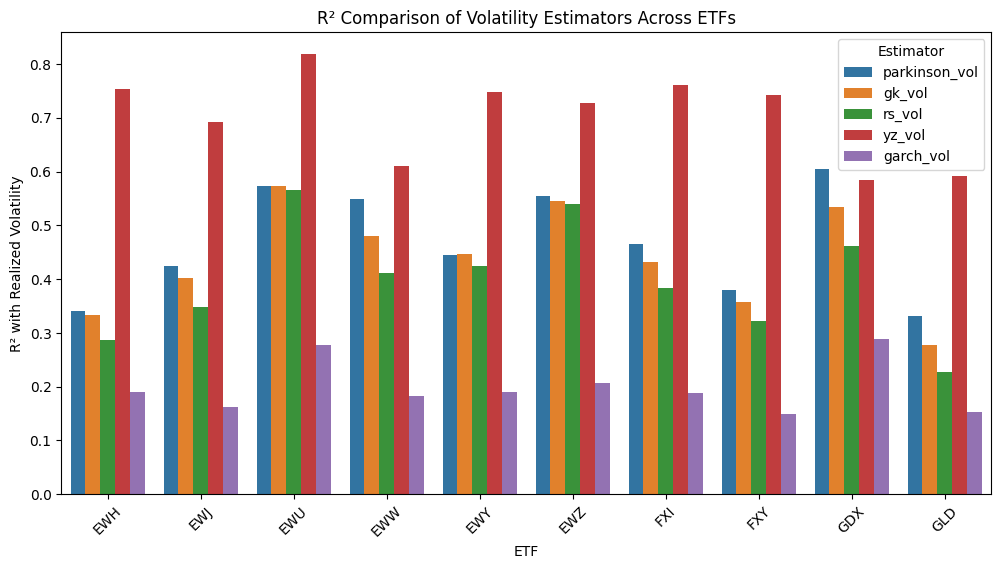

In [73]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_plot, x='ETF', y='R2', hue='Estimator')
plt.title('R² Comparison of Volatility Estimators Across ETFs')
plt.xticks(rotation=45)
plt.ylabel('R² with Realized Volatility')
plt.legend(title='Estimator')
plt.show()

#### As we can see the Yang-Zang estimator is the best among all the vol with mean R^2 ~ 70%

### Taking avg of R^2 and MSE for each of the estimator to judge the performace of each estimator across 10 ETFs

In [76]:
summary = df_plot.groupby('Estimator')[['R2', 'MSE']].mean().reset_index()
summary = summary.sort_values('R2', ascending=False)  # sort by R²
summary

,Estimator,R2,MSE
4,yz_vol,0.702869,0.005989
2,parkinson_vol,0.466879,0.014819
1,gk_vol,0.438207,0.015305
3,rs_vol,0.397020,0.015813
0,garch_vol,0.198891,0.016231


#### Average R^2 of all estimators across 10 ETFs

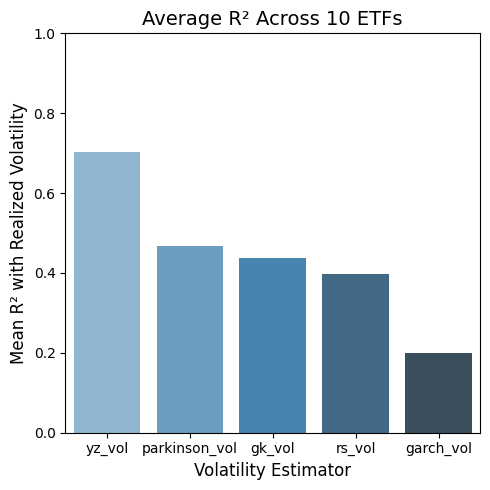

In [158]:
fig, ax1 = plt.subplots(figsize=(5,5))
sns.barplot(data=summary, x='Estimator', y='R2', hue='Estimator',palette='Blues_d',legend=False)
plt.title('Average R² Across 10 ETFs', fontsize=14)
plt.ylabel('Mean R² with Realized Volatility', fontsize=12)
plt.xlabel('Volatility Estimator', fontsize=12)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

#### Average MSE of all estimators across 10 ETFs

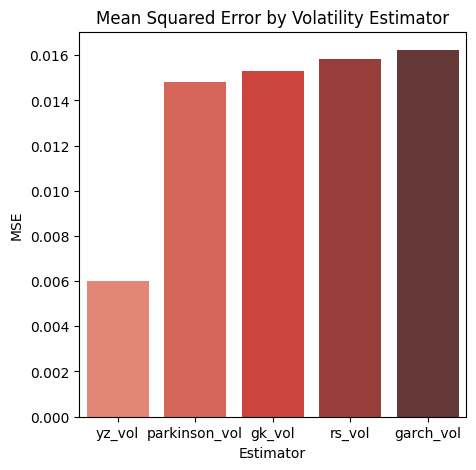

In [164]:
fig, ax1 = plt.subplots(figsize=(5,5))
sns.barplot(data=summary, x='Estimator', y='MSE', hue='Estimator', palette='Reds_d', legend=False)
plt.title("Mean Squared Error by Volatility Estimator")
plt.ylabel("MSE")
plt.xlabel("Estimator")
plt.show()

#### Combining both the graph for better visibility

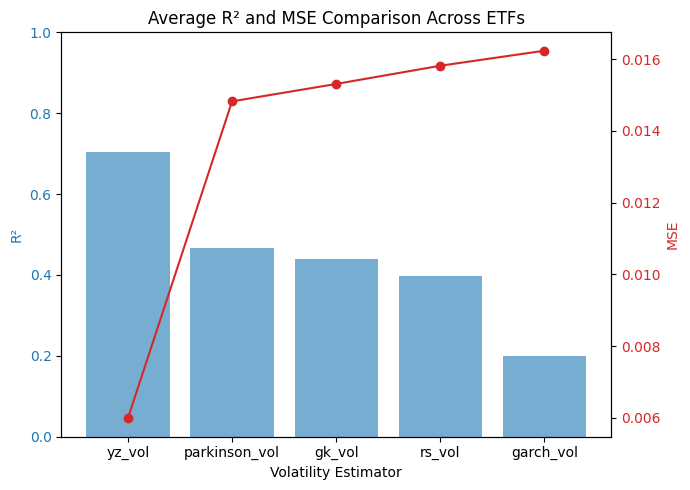

In [170]:
fig, ax1 = plt.subplots(figsize=(7,5))

color = 'tab:blue'
ax1.set_xlabel('Volatility Estimator')
ax1.set_ylabel('R²', color=color)
ax1.bar(summary['Estimator'], summary['R2'], color=color, alpha=0.6, label='R²')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()  # second axis
color = 'tab:red'
ax2.set_ylabel('MSE', color=color)
ax2.plot(summary['Estimator'], summary['MSE'], color=color, marker='o', label='MSE')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Average R² and MSE Comparison Across ETFs')
fig.tight_layout()
plt.show()


### Conclusion

From the comparative analysis of six volatility estimators across the selected ETFs, the **Yang–Zhang (YZ)** model demonstrates the best overall forecasting performance. As seen in the chart, **YZ volatility exhibits the highest average $R^2$** indicating the strongest explanatory power for realized volatility and maintains a **least MSE**, implying stable prediction accuracy.

In contrast, range-based estimators like Parkinson and Garman–Klass perform reasonably well but slightly lag behind YZ due to their sensitivity to intraday noise and opening price gaps. The **GARCH(1,1)** model, while theoretically robust for dynamic volatility modeling, shows higher MSE and lower $R^2$ in this backtest, suggesting that short historical windows and parameter estimation error reduce its short-term forecasting accuracy relative to simpler realized estimators.

Therefore, if making investment or risk management decisions, the **Yang–Zhang estimator** would be preferred for its balance of responsiveness and robustness. It efficiently incorporates overnight jumps, intraday ranges, and open–close variations, providing a comprehensive view of realized market volatility suitable for portfolio volatility targeting and option pricing applications.